### Kelly Criterion: Theory and Intuition

The Kelly Criterion, developed by John L. Kelly Jr. in 1956, is a mathematical formula that determines the optimal fraction of capital to allocate to a risky bet or investment in order to maximize the long-term growth rate of wealth. Unlike traditional portfolio optimization that targets a single-period mean-variance trade-off, the Kelly Criterion maximizes the expected value of the logarithm of wealth, which is equivalent to maximizing the geometric growth rate over time.

<b>The core idea:</b> For a single asset, the continuous Kelly fraction is:
$$f^* = \frac{\mu - r_f}{\sigma^2}$$

where $\mu$ is the expected return, $r_f$ is the risk-free rate, and $\sigma^2$ is the variance of returns.

For a portfolio of $n$ correlated assets, the Kelly Criterion generalizes to a quadratic optimization problem:
$$f^* = arg max_w [w^T(\mu - r_f)-\frac{1}{2}w^T \Sigma w]$$

where $w$ is the vector of portfolio weights, $\mu - r_f$ is the vector of excess returns, and $\Sigma$ is the covariance matrix. This is mathematically identical to maximizing quadratic utility with a risk aversion parameter $\lambda = 1$

The Kelly Criterion is a special case of mean-variance optimization where the risk aversion parameter $\lambda$ equals 1. This project uses the `pypfopt` library's `max_quadratic_utility` to solve this optimization, which yields the full Kelly weights. These are then scaled by 0.5 to obtain Half Kelly allocations.

In [1]:
import pandas as pd
import numpy as np

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns
import squarify

from sklearn.covariance import LedoitWolf

from pypfopt import EfficientFrontier

We define our initial investment universe as 9 stocks from the Pakistan Stock Exchange (PSX) Oil & Gas sector. The `.KA` suffix denotes Karachi Stock Exchange listings. The time horizon spans from *January 2020 to December 2025*, providing approximately 6 years of daily price data covering multiple market regimes including the COVID-19 crash and recovery.

In [2]:
tickers = [
    'OGDC.KA', 'PPL.KA', 'MARI.KA', 'PSO.KA', 'APL.KA', 'ATRL.KA', 'NRL.KA', 'SSGC.KA', 'PRL.KA'
]
start = '2020-01-01'
end = '2025-12-31'

|Ticker|Bank|
|:------|:----|
|OGDC.KA|Oil & Gas Development Company|
|PPL.KA|Pakistan Petroleum Limited|
|MARI.KA|Mari Energies Limited|
|PSO.KA|Pakistan State Oil|
|APL.KA|Attock Petroleum Limited|
|ATRL.KA|Attock Refinery Limited|
|NRL.KA|National Refinery Limited|
|SSGC.KA|Sui Southern Gas Company|
|PRL.KA|Pakistan Refinery Limited|

We use yfinance to download adjusted closing prices for all 9 tickers.

In [3]:
price = yf.download(tickers=tickers, start=start, end=end, auto_adjust=True)['Close']

[*********************100%***********************]  9 of 9 completed


In [4]:
print(price.shape)
price.head()

(1547, 9)


Ticker,APL.KA,ATRL.KA,MARI.KA,NRL.KA,OGDC.KA,PPL.KA,PRL.KA,PSO.KA,SSGC.KA
Date,,,,,,,,,
2020-01-01,183.923645,98.221252,1171.981323,133.293701,88.790405,109.755341,14.734298,149.739334,21.868313
2020-01-02,185.609528,102.150787,1180.839233,139.563034,91.424583,113.343185,15.465646,157.222473,22.489178
2020-01-03,187.460464,99.875343,1165.731689,135.157303,92.865875,113.668640,15.801126,158.677734,22.025993
2020-01-06,182.763092,95.559593,1141.409546,128.417542,92.294327,111.112701,15.016101,153.423447,20.932083
2020-01-07,185.484467,100.337158,1152.814087,134.831619,92.573906,111.446091,15.760867,160.592560,21.405125


In [5]:
price.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1547 entries, 2020-01-01 to 2025-12-30
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   APL.KA   1547 non-null   float64
 1   ATRL.KA  1547 non-null   float64
 2   MARI.KA  1547 non-null   float64
 3   NRL.KA   1547 non-null   float64
 4   OGDC.KA  1547 non-null   float64
 5   PPL.KA   1547 non-null   float64
 6   PRL.KA   1547 non-null   float64
 7   PSO.KA   1547 non-null   float64
 8   SSGC.KA  1547 non-null   float64
dtypes: float64(9)
memory usage: 120.9 KB


In [6]:
price.isna().sum()

Ticker
APL.KA     0
ATRL.KA    0
MARI.KA    0
NRL.KA     0
OGDC.KA    0
PPL.KA     0
PRL.KA     0
PSO.KA     0
SSGC.KA    0
dtype: int64

We check for missing values across all columns. Zero missing values indicates that yfinance returned complete data for all 9 stocks over the entire period. No imputation is needed.

In [7]:
price.duplicated().sum()

np.int64(68)

68 duplicate rows are detected. These typically occur when yfinance forward-fills prices on non-trading days, like public holidays.

In [8]:
# Shows all rows that belong to any duplicate group
price[price.duplicated(keep=False)]

Ticker,APL.KA,ATRL.KA,MARI.KA,NRL.KA,OGDC.KA,PPL.KA,PRL.KA,PSO.KA,SSGC.KA
Date,,,,,,,,,
2020-02-04,166.088379,93.519272,1168.883301,126.472504,82.105675,106.175407,13.694308,157.459915,18.911804
2020-02-05,166.088379,93.519272,1168.883301,126.472504,82.105675,106.175407,13.694308,157.459915,18.911804
2020-03-20,131.133087,61.906769,882.428772,82.053337,57.037849,64.494255,10.480677,104.036285,11.845747
2020-03-23,131.133087,61.906769,882.428772,82.053337,57.037849,64.494255,10.480677,104.036285,11.845747
2020-04-30,129.970306,70.529877,1041.897095,91.534256,66.633179,72.495522,12.287372,118.274933,13.501391
...,...,...,...,...,...,...,...,...,...
2025-06-16,438.699463,660.321533,603.834167,243.539993,199.005005,161.547333,32.169998,361.054382,40.918087
2025-09-22,491.007660,665.882446,664.333557,369.769989,267.398071,186.356155,35.610001,440.859863,43.303001
2025-09-23,491.007660,665.882446,664.333557,369.769989,267.398071,186.356155,35.610001,440.859863,43.303001


We remove duplicate dates by keeping only the first occurrence of each date. This ensures that when we compute daily returns, we do not introduce artificial zero-return days that would deflate measured volatility and distort the covariance matrix.

In [9]:
price = price[~price.index.duplicated(keep='first')]

We compute continuously compounded (logarithmic) returns. Log returns are used instead of arithmetic returns because the Kelly Criterion maximizes expected log-wealth. Log returns are additive over time.

In [10]:
df = np.log(price).diff().dropna()

We annualize daily mean log returns by multiplying by 252. This gives us the expected annual continuously compounded return for each stock.

In [11]:
annual_return = df.mean() * 252

We annualize daily standard deviation by multiplying by $\sqrt{252}$. 

In [12]:
annual_volatility = df.std() * np.sqrt(252)

We load the Pakistani Treasury bill rate and compute the average rate over the sample period.

In [13]:
risk_free_rate = pd.read_csv('data_series.csv')
risk_free_rate = risk_free_rate['Observation Value']/100
risk_free_rate = risk_free_rate.mean()

In [14]:
print(f'The risk-free-rate of Pakistan during the time horizon selected is {risk_free_rate:.4f}')

The risk-free-rate of Pakistan during the time horizon selected is 0.1351


We compute the annualized Sharpe ratio for each stock as:
$$Sharpe_i = \frac{\mu_i - r_f}{\sigma_i}$$

In [15]:
annual_sharp = (annual_return - risk_free_rate) / annual_volatility

In [16]:
annual_summary = pd.DataFrame(
    {
        'annual_return': annual_return,
        'annual_volatility': annual_volatility,
        'annual_sharpe': annual_sharp
    }
)
annual_summary

,annual_return,annual_volatility,annual_sharpe
Ticker,,,
APL.KA,0.171384,0.280524,0.129472
ATRL.KA,0.317839,0.459512,0.397759
MARI.KA,-0.081849,0.948310,-0.228736
NRL.KA,0.186704,0.489505,0.105494
OGDC.KA,0.185175,0.344373,0.145514
PPL.KA,0.122397,0.371266,-0.034117
PRL.KA,0.153137,0.491063,0.036804
PSO.KA,0.187670,0.352447,0.149260
SSGC.KA,0.084658,0.454504,-0.110902


MARI.KA shows an anomalously high annualized volatility of 94.83%, roughly double any other stock in the universe. This warrants further investigation before proceeding with covariance estimation, as a single outlier can distort the entire covariance matrix.

In [17]:
df['MARI.KA'].describe()

count    1546.000000
mean       -0.000325
std         0.059738
min        -2.211246
25%        -0.006857
50%         0.000000
75%         0.006952
max         0.095315
Name: MARI.KA, dtype: float64

The minimum value of -2.211 is an extreme outlier.

In [18]:
outlier_date = df['MARI.KA'].idxmin()
outlier_value = df.loc[outlier_date, 'MARI.KA']

print(f"Outlier date: {outlier_date}")
print(f"Log return: {outlier_value:.6f}")
print(f"Implied price drop: {(np.exp(outlier_value) - 1):.2%}")

# Check the raw prices around that date
print("\nPrice context:")
print(price.loc[outlier_date - pd.Timedelta(days=5):outlier_date + pd.Timedelta(days=5), 'MARI.KA'])

Outlier date: 2024-09-05 00:00:00
Log return: -2.211246
Implied price drop: -89.04%

Price context:
Date
2024-09-02    3170.065430
2024-09-03    3231.328369
2024-09-04    3351.617188
2024-09-05     367.216919
2024-09-06     371.433441
2024-09-09     373.156647
2024-09-10     375.228638
Name: MARI.KA, dtype: float64


We locate the exact date of the extreme return and examine the surrounding price context. The output reveals:
<ul>
<li>On September 5, 2024, MARI.KA's price drops from PKR 3,351.62 to PKR 367.22. A ratio of approximately 9:1.</li>
<li>This is consistent with a stock split (likely 9:1 or 10:1) that yfinance failed to adjust for.</li>
<li>Post-split prices (PKR 367–375) are stable, confirming this is not a genuine crash.</li>
</ul>

*Mari Petroleum* (MARI.KA) is excluded from the analysis due to a stock split on September 5, 2024 that was not properly adjusted in the yfinance data feed, resulting in a spurious -89% daily return. Since the Kelly Criterion assigns zero weight to negative-Sharpe assets, this exclusion does not materially affect portfolio construction, but ensures clean covariance estimation for the remaining 8 Oil & Gas sector stocks.

In [19]:
print(f"The Maximum Annual Sharpe is given by {annual_sharp.idxmax()}, which is {annual_sharp.max():.4f}")

The Maximum Annual Sharpe is given by ATRL.KA, which is 0.3978


In [20]:
# Final universe after data quality screening
tickers_clean = [
    'OGDC.KA', 'PPL.KA', 'PSO.KA', 'APL.KA', 
    'ATRL.KA', 'NRL.KA', 'SSGC.KA', 'PRL.KA'
]

We encapsulate the data pipeline (download, log returns, annualized metrics) into a reusable function.

In [21]:
def data_wrangling(tickers, start, end, risk_free_rate):
    price = yf.download(tickers=tickers_clean, start=start, end=end, auto_adjust=True)['Close']
    df = np.log(price).diff().dropna()
    annual_ret = df.mean() * 252
    annual_vol = df.std() * np.sqrt(252)
    annual_sharpe = (annual_ret - risk_free_rate) / annual_vol
    return price, df, annual_ret, annual_vol, annual_sharpe

In [22]:
price_clean, df_clean, annual_ret_clean, annual_vol_clean, annual_sharpe_clean = data_wrangling(
    tickers=tickers_clean, start=start, end=end, risk_free_rate=risk_free_rate
)

[*********************100%***********************]  8 of 8 completed


In [23]:
annual_sum_clean = pd.DataFrame(
    {
        "annual_ret": annual_ret_clean,
        "annual_vol": annual_vol_clean,
        "annual_shp": annual_sharpe_clean
    }
)
annual_sum_clean

,annual_ret,annual_vol,annual_shp
Ticker,,,
APL.KA,0.171384,0.280524,0.129472
ATRL.KA,0.317839,0.459512,0.397759
NRL.KA,0.186704,0.489505,0.105494
OGDC.KA,0.185175,0.344373,0.145514
PPL.KA,0.122397,0.371266,-0.034117
PRL.KA,0.153137,0.491063,0.036804
PSO.KA,0.187670,0.352447,0.149260
SSGC.KA,0.084658,0.454504,-0.110902


We plot the cumulative growth of a hypothetical 1 PKR investment in each stock from January 2020.

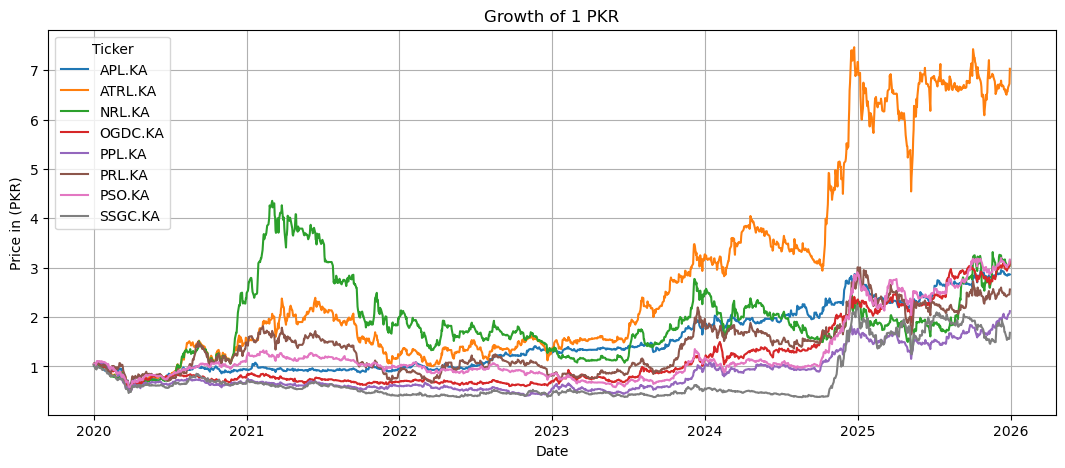

In [24]:
plt.figure(figsize=(13,5))
growth = np.exp(df_clean.cumsum())
sns.lineplot(growth, dashes=False)
plt.title('Growth of 1 PKR')
plt.ylabel('Price in (PKR)')
plt.grid(True)
plt.savefig('growth_of_1pkr_plot.jpg')

In [25]:
print(f"The highest growth of 1PKR is given by {growth.iloc[-1].idxmax()}, which is {growth.iloc[-1].max():.4f}.")

The highest growth of 1PKR is given by ATRL.KA, which is 7.0281.


In [26]:
start_price = price.loc[start, 'ATRL.KA']
end_price = price.loc['2025-12-30', 'ATRL.KA']
direct_price_ratio = end_price / start_price
print(f'Direct Price ratio: {direct_price_ratio:.4f}')

Direct Price ratio: 7.0281


We verify the growth calculation by computing the direct ratio of end price to start price for ATRL.KA. The result *(7.0281)* matches the cumulative growth chart exactly, confirming our log-return methodology is correct.

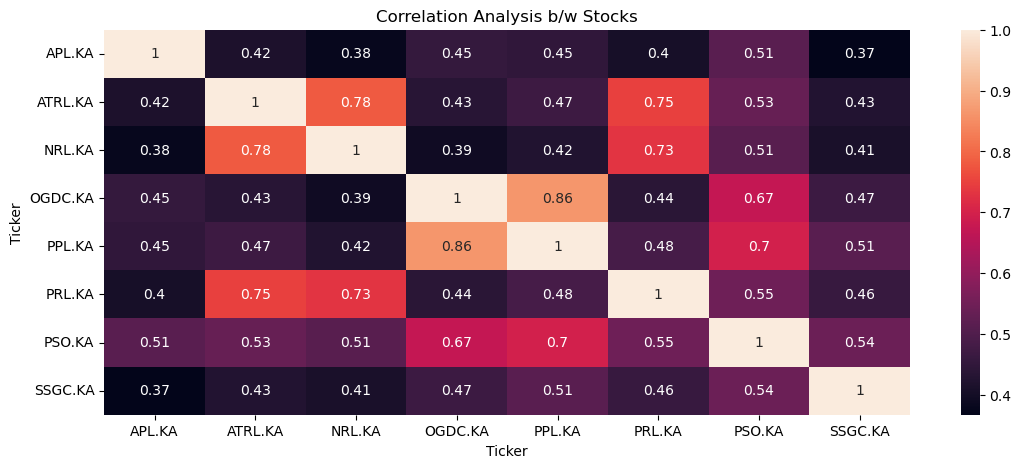

In [27]:
plt.figure(figsize=(13,5))
sns.heatmap(df_clean.corr(), annot=True)
plt.title('Correlation Analysis b/w Stocks')
plt.savefig('correlation_plot.jpg');

We visualize pairwise correlations between the 8 stocks. Notable patterns:
<ul>
<li>OGDC–PPL have the highest correlation (0.86), as both are large-cap exploration & production companies.</li>
<li>ATRL–NRL are highly correlated (0.78), both being refineries.</li>
<li>ATRL–PRL are also strongly correlated (0.75).</li>
<li>MARI (now excluded) had the weakest correlations with the group.</li>
</ul>

We compute the annualized sample covariance matrix by multiplying the daily covariance by 252.

In [28]:
cov_simple = df_clean.cov() * 252

We define a function that computes the Ledoit-Wolf shrinkage covariance estimator.<br> This method optimally combines the sample covariance matrix with a structured target (scaled identity matrix) to reduce estimation error:
$$\hat{\Sigma_{LW}} = (1-\delta) \hat{\Sigma_{sample}} + \delta . F$$
where $\delta$ is the shrinkage intensity and $F$ is the target matrix.

In [29]:
def ledoit_wolf_cov(df):
    lw = LedoitWolf().fit(df.values)
    cov = pd.DataFrame(lw.covariance_ * 252, index = df.columns, columns=df.columns)
    shrinkage = lw.shrinkage_
    return cov, shrinkage

In [30]:
cov_lw, delta_lw = ledoit_wolf_cov(df_clean)

In [31]:
delta_lw

np.float64(0.005930962638442585)

The shrinkage coefficient $\delta = 0.0059$ (0.59%) indicates that the sample covariance matrix is very reliable and requires almost no shrinkage.

In [32]:
vol_simple = np.sqrt(np.diag(cov_simple))
vol_lw = np.sqrt(np.diag(cov_lw))

In [33]:
vol_comparison = pd.DataFrame(
    {
        'vol_simple': vol_simple,
        'vol_lw': vol_lw
    }
)
vol_comparison

,vol_simple,vol_lw
0,0.280524,0.281394
1,0.459512,0.459096
2,0.489505,0.488923
3,0.344373,0.344701
4,0.371266,0.371401
5,0.491063,0.490473
6,0.352447,0.352715
7,0.454504,0.454117


In [34]:
eigen_simple = np.sort(np.linalg.eigvalsh(cov_simple))[::-1]
eigen_lw = np.sort(np.linalg.eigvalsh(cov_lw))[::-1]

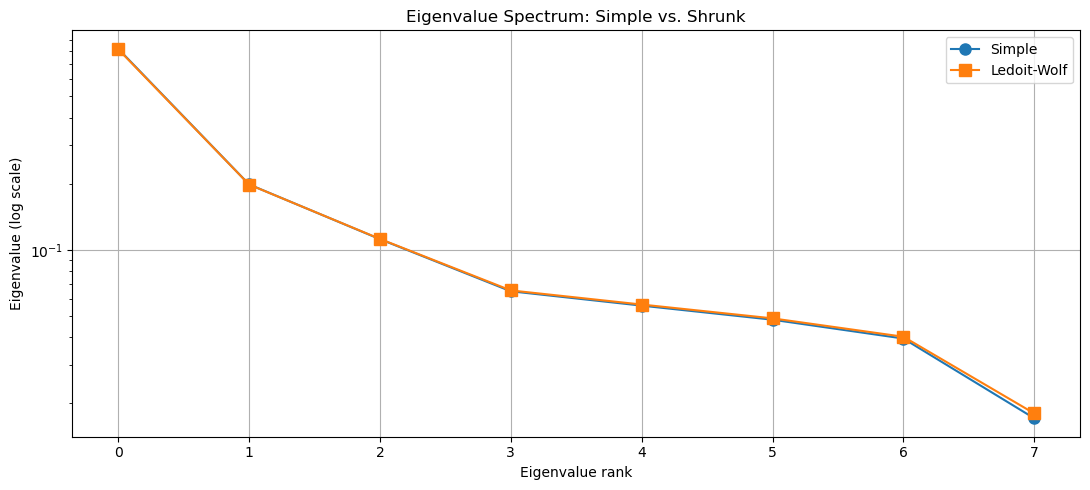

In [35]:
plt.figure(figsize=(11, 5))
plt.plot(eigen_simple, 'o-', label='Simple', markersize=8)
plt.plot(eigen_lw, 's-', label='Ledoit-Wolf', markersize=8)
plt.yscale('log')
plt.xlabel('Eigenvalue rank')
plt.ylabel('Eigenvalue (log scale)')
plt.title('Eigenvalue Spectrum: Simple vs. Shrunk')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('eiganvalue_spectrum_plot.jpg')
plt.show()

We compute and plot the eigenvalues of both covariance matrices on a log scale. The eigenvalue spectrum reveals:
<ul>
<li>A smooth, monotonically decreasing curve.</li>
<li>Simple and Ledoit-Wolf spectra nearly overlap (consistent with low shrinkage).</li>
<li>No extreme outlier eigenvalue</li>
</ul>

We compute excess returns by subtracting the risk-free rate from each stock's annualized return.

In [36]:
excess_mu = annual_ret_clean - risk_free_rate

We construct a new `EfficientFrontier` object with position limits of 0% to 20% per stock. This constraint reflects practical portfolio management concerns:
<ul>
<li>No single stock should dominate the portfolio (concentration risk).</li>
<li>Regulatory or mandate limits may restrict individual position sizes.</li>
<li>Estimation error in returns makes concentrated bets risky.</li>
</ul>

In [37]:
ef = EfficientFrontier(excess_mu, cov_lw, weight_bounds=(0, 0.20))

We solve the Kelly optimization with $\lambda = 1$, this maximizes:
$$U(w) = w^T(\mu - r_f) - \frac{1}{2} w^T \Sigma w$$
which is the continuous-time approximation to maximizing expected log-wealth growth.

In [38]:
raw_weights = ef.max_quadratic_utility(risk_aversion=1.0)

We round the optimized weights to remove floating-point noise.

In [39]:
clean_weights = ef.clean_weights()

We scale all weights by *0.5* to obtain the `Half Kelly` allocation.

In [40]:
half_kelly_weights = {t: w * 0.5 for t, w in clean_weights.items()}
cash_position = 1 - sum(half_kelly_weights.values())
print(f"Implied cash position: {cash_position:.2%}")

Implied cash position: 50.00%


The implied cash position is 50%, meaning Half Kelly recommends holding half the portfolio in risk-free assets.

In [41]:
half_kelly_weights

{'APL.KA': 0.1,
 'ATRL.KA': 0.1,
 'NRL.KA': 0.1,
 'OGDC.KA': 0.1,
 'PPL.KA': 0.0,
 'PRL.KA': 0.0,
 'PSO.KA': 0.1,
 'SSGC.KA': 0.0}

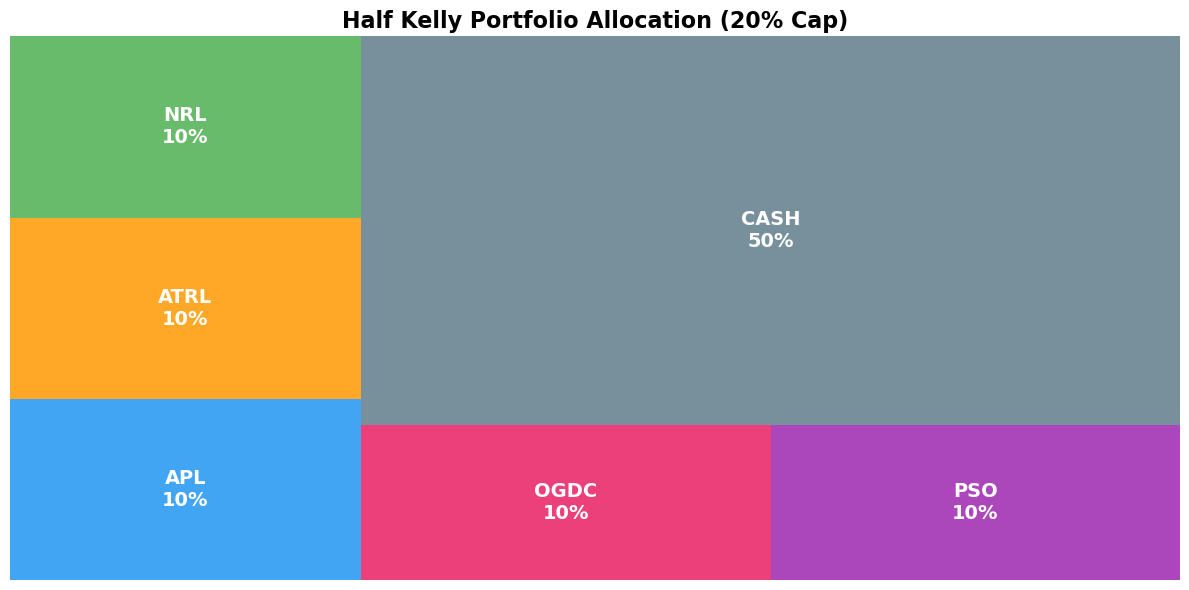

In [42]:
# Treemap of Half Kelly Portfolio Allocation
labels = []
sizes = []
for ticker, weight in half_kelly_weights.items():
    if weight > 0:
        labels.append(f"{ticker.replace('.KA','')}\n{weight:.0%}")
        sizes.append(weight)

# Add cash position
cash = 1 - sum(half_kelly_weights.values())
labels.append(f"CASH\n{cash:.0%}")
sizes.append(cash)

colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0', '#607D8B']

plt.figure(figsize=(12, 6))
squarify.plot(sizes=sizes, label=labels, color=colors,
              alpha=0.85, text_kwargs={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'})
plt.title('Half Kelly Portfolio Allocation (20% Cap)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('treemap_allocation_plot.jpg')
plt.show()

The Half Kelly portfolio (with 20% cap) allocates:

10% each to APL, ATRL, NRL, OGDC, and PSO (5 stocks at equal effective cap)
0% to PPL, PRL, and SSGC (negative or near-zero Sharpe ratios)
50% to cash (earning the risk-free rate of 13.51%)

We compute the total portfolio performance including the cash position.

In [43]:
w = np.array(list(half_kelly_weights.values()))

risky_weight = sum(half_kelly_weights.values())       # 0.50
cash_return  = (1 - risky_weight) * risk_free_rate    # 0.50 × 0.1351

total_port_return = (w @ annual_ret_clean.values) + cash_return
port_vol    = np.sqrt(w @ cov_lw.values @ w)
port_sharpe = (total_port_return - risk_free_rate) / port_vol

print(f"Risky Weight:    {risky_weight:.2%}")
print(f"Cash Weight:     {1 - risky_weight:.2%}")
print(f"Expected Return: {total_port_return:.2%}")
print(f"Volatility:      {port_vol:.2%}")
print(f"Sharpe Ratio:    {port_sharpe:.4f}")

Risky Weight:    50.00%
Cash Weight:     50.00%
Expected Return: 17.24%
Volatility:      15.15%
Sharpe Ratio:    0.2464


Results:

**Expected Return:** 17.24%, modest excess over the 13.51% risk-free rate, reflecting the high hurdle rate in Pakistan.<br>
**Volatility:** 15.15%, well below individual stock volatilities (28–49%), demonstrating diversification benefit.<br>
**Sharpe Ratio:** 0.2464, positive but modest, consistent with a constrained, conservative allocation.<br>

Limitation in Our Implementation:

<ol>
    <li>
        <b>In-Sample Estimation (No Walk-Forward Validation):</b> We estimate returns and covariance over the full 2020–2025 period and then evaluate the portfolio as if these estimates were known in advance. This introduces look-ahead bias. A more rigorous approach would use rolling-window or walk-forward estimation.
    </li>
    <li>
        <b>Single-Sector Universe:</b> Our universe consists entirely of Oil & Gas stocks from the Pakistan Stock Exchange. This limits diversification, the high pairwise correlations (0.37–0.86) mean we cannot construct a truly diversified portfolio.
    </li>
    <li>
        <b>Data Quality Constraints:</b> e identified and excluded MARI.KA due to an unadjusted stock split in the yfinance data feed. Other, less obvious data errors may persist in the remaining 8 stocks.
    </li>
    <li>
        <b>Static Risk-Free Rate:</b> We use the average T-bill rate over the entire period (13.51%), but Pakistan's monetary policy rate fluctuated significantly during 2020–2025 (from ~7% to ~22%). A time-varying risk-free rate would produce different excess return estimates and potentially different Kelly allocations at different points in time.
    </li>
    <li>
        <b>No Out-of-Sample Backtest:</b> We report expected return and Sharpe based on the same data used to estimate parameters. A proper backtest would compute realized portfolio returns using weights derived from past data only, providing a more honest assessment of strategy performance.
    </li>
</ol>